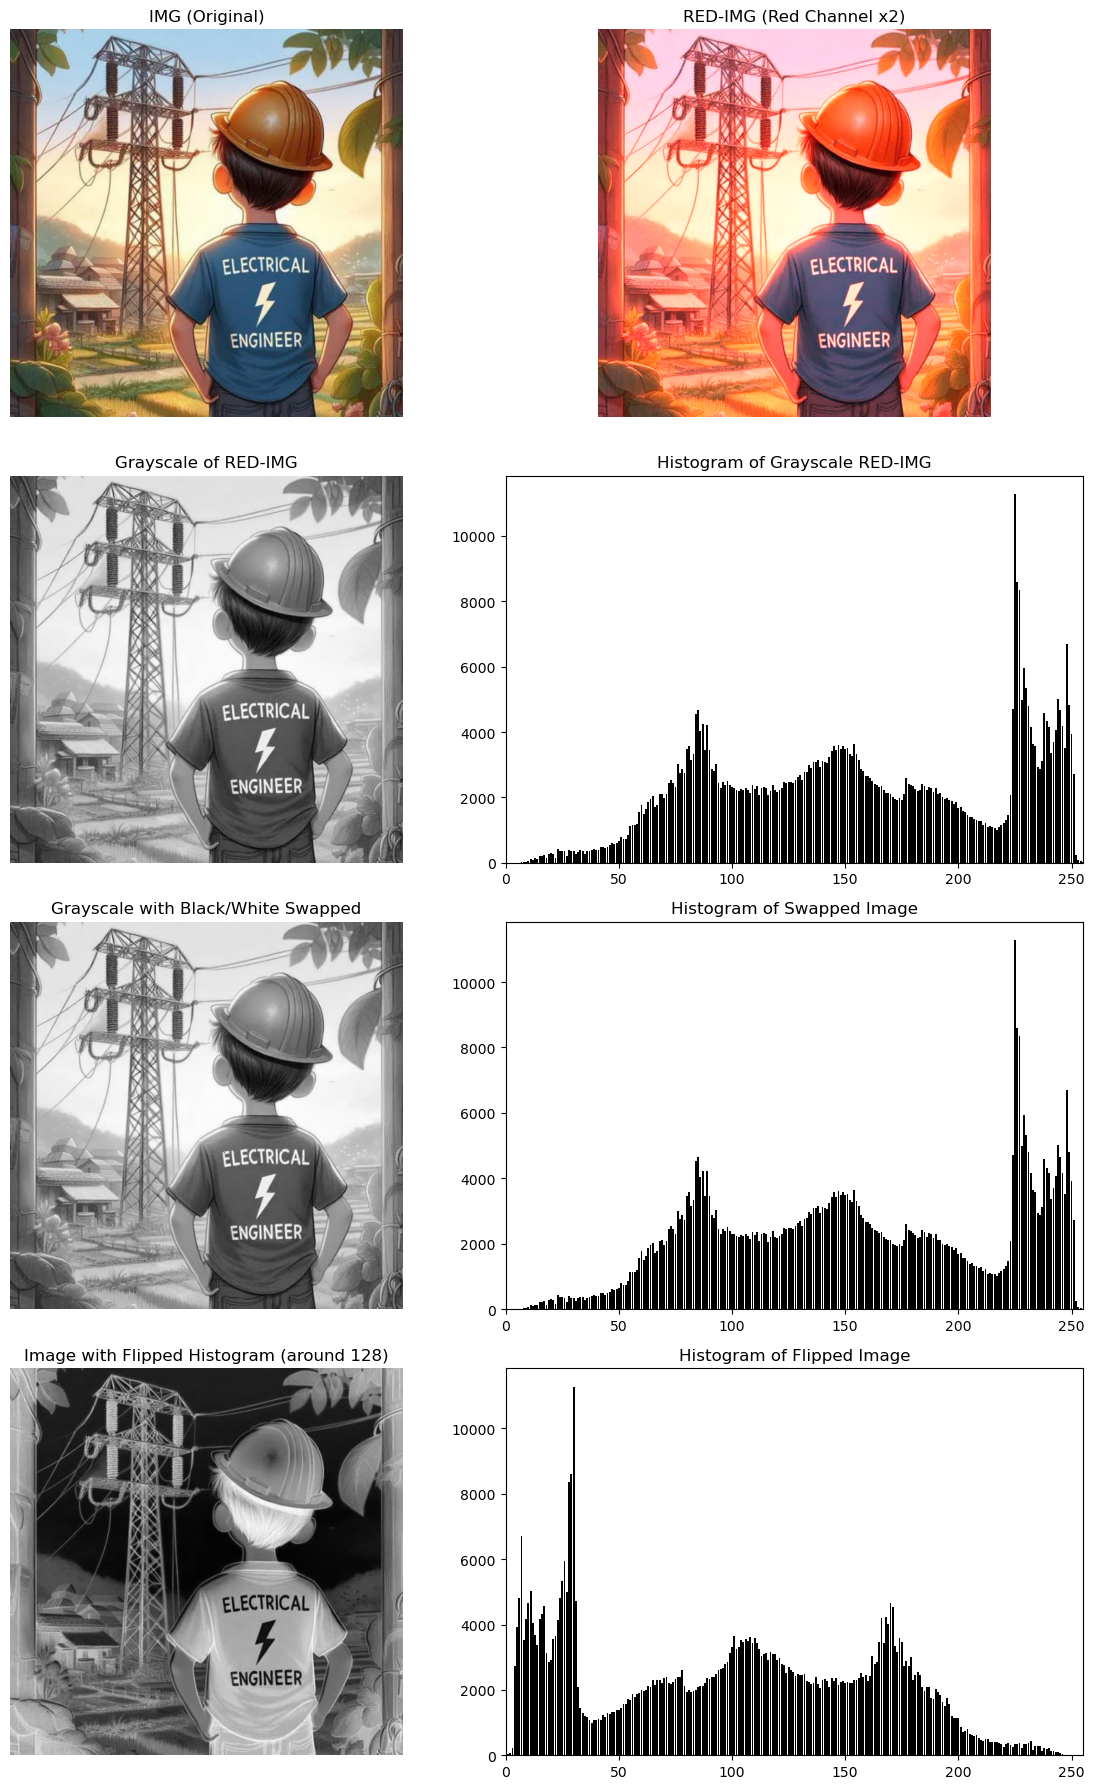

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

class ImageProcessor:
    def __init__(self, img_path):
        # 1. خواندن تصویر رنگی
        self.IMG = cv2.imread(img_path)
        if self.IMG is None:
            raise FileNotFoundError("تصویر یافت نشد.")
        
        # تبدیل BGR (OpenCV) به RGB (Matplotlib)
        self.IMG = cv2.cvtColor(self.IMG, cv2.COLOR_BGR2RGB)
        
        self.original_h, self.original_w = self.IMG.shape[:2]
        
        # متغیرهای ذخیره‌سازی برای تصاویر تولیدی
        self.RED_IMG = None
        self.gray_IMG = None
        self.gray_RED_IMG = None
        self.inverted_BW_IMG = None
        self.flipped_hist_IMG = None

    def compute_histogram(self, img):
        """محاسبه هیستوگرام یک تصویر خاکستری (0-255)"""
        if len(img.shape) == 3:
            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        else:
            gray = img
        hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
        return hist.flatten()

    def create_RED_IMG(self):
        """ایجاد تصویر RED-IMG با دو برابر کردن کانال قرمز و برش در 255"""
        r, g, b = cv2.split(self.IMG)
        # دو برابر کردن کانال قرمز با محدودیت حداکثر 255
        r_boosted = np.clip(r.astype(np.int32) * 2, 0, 255).astype(np.uint8)
        self.RED_IMG = cv2.merge([r_boosted, g, b])
        return self.RED_IMG

    def swap_black_white_gray(self, gray_img):
        """تعویض پیکسل‌های کاملاً سفید (255) و کاملاً سیاه (0) در تصویر خاکستری"""
        result = gray_img.copy()
        # نقاب پیکسل‌های سفید (255)
        white_mask = gray_img == 255
        # نقاب پیکسل‌های سیاه (0)
        black_mask = gray_img == 0
        
        result[white_mask] = 0
        result[black_mask] = 255
        return result

    def flip_histogram_image(self, gray_img):
        """وارون کردن هیستوگرام حول شدت 128 (تعویض سمت چپ و راست)"""
        lookup_table = 255 - np.arange(256, dtype=np.uint8)
        flipped = cv2.LUT(gray_img, lookup_table)
        return flipped

    def process_and_plot(self):
        """اجرای تمامی عملیات و رسم subplot 4x2"""
        
        # 1. ایجاد تصویر RED-IMG
        self.create_RED_IMG()
        
        # 2. تبدیل به خاکستری
        self.gray_IMG = cv2.cvtColor(self.IMG, cv2.COLOR_RGB2GRAY)
        self.gray_RED_IMG = cv2.cvtColor(self.RED_IMG, cv2.COLOR_RGB2GRAY)
        
        # 3. محاسبه هیستوگرام‌ها
        hist_gray = self.compute_histogram(self.gray_IMG)
        hist_red_gray = self.compute_histogram(self.gray_RED_IMG)
        
        # 4. تعویض سیاه و سفید در نسخه خاکستری RED-IMG
        self.inverted_BW_IMG = self.swap_black_white_gray(self.gray_RED_IMG)
        hist_inverted_BW = self.compute_histogram(self.inverted_BW_IMG)
        
        # 5. وارون هیستوگرام حول 128
        self.flipped_hist_IMG = self.flip_histogram_image(self.gray_RED_IMG)
        hist_flipped = self.compute_histogram(self.flipped_hist_IMG)
        
        # ============= رسم Subplot 4x2 =============
        plt.figure(figsize=(12, 18))
        
        # ردیف 1، ستون 1: IMG اصلی
        plt.subplot(4, 2, 1)
        plt.imshow(self.IMG)
        plt.title('IMG (Original)')
        plt.axis('off')
        
        # ردیف 1، ستون 2: RED-IMG
        plt.subplot(4, 2, 2)
        plt.imshow(self.RED_IMG)
        plt.title('RED-IMG (Red Channel x2)')
        plt.axis('off')
        
        # ردیف 2، ستون 1: معادل خاکستری RED-IMG
        plt.subplot(4, 2, 3)
        plt.imshow(self.gray_RED_IMG, cmap='gray')
        plt.title('Grayscale of RED-IMG')
        plt.axis('off')
        
        # ردیف 2، ستون 2: هیستوگرام خاکستری RED-IMG
        plt.subplot(4, 2, 4)
        plt.bar(range(256), hist_red_gray, color='black')
        plt.title('Histogram of Grayscale RED-IMG')
        plt.xlim([0, 255])
        
        # ردیف 3، ستون 1: تصویر با تعویض سیاه/سفید (نسخه خاکستری)
        plt.subplot(4, 2, 5)
        plt.imshow(self.inverted_BW_IMG, cmap='gray')
        plt.title('Grayscale with Black/White Swapped')
        plt.axis('off')
        
        # ردیف 3، ستون 2: هیستوگرام تصویر تعویض‌شده
        plt.subplot(4, 2, 6)
        plt.bar(range(256), hist_inverted_BW, color='black')
        plt.title('Histogram of Swapped Image')
        plt.xlim([0, 255])
        
        # ردیف 4، ستون 1: تصویر با هیستوگرام وارون‌شده
        plt.subplot(4, 2, 7)
        plt.imshow(self.flipped_hist_IMG, cmap='gray')
        plt.title('Image with Flipped Histogram (around 128)')
        plt.axis('off')
        
        # ردیف 4، ستون 2: هیستوگرام تصویر وارون‌شده
        plt.subplot(4, 2, 8)
        plt.bar(range(256), hist_flipped, color='black')
        plt.title('Histogram of Flipped Image')
        plt.xlim([0, 255])
        
        plt.tight_layout()
        plt.savefig('m.png')
        plt.show()

p = ImageProcessor('ele.png')
p.process_and_plot()